<a href="https://colab.research.google.com/github/NatashaMyruta/Machine-Learning/blob/main/%D0%9B%D0%A05_%D0%9C%D0%9D_%D0%9C%D0%B8%D1%80%D1%83%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Мирута Наталія Романівна
ФІТ 3-15


In [8]:
# Встановлення необхідних бібліотек (для Colab)
!pip install prophet pandas numpy matplotlib seaborn statsmodels scikit-learn tensorflow

# Імпорт бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Для Prophet
from prophet import Prophet

# Для LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Налаштування відображення графіків
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [9]:
#  Завантажити файл з комп'ютера
from google.colab import files
print("Завантажте файл kaggel_weather_2013_to_2024.csv")
uploaded = files.upload()

df = pd.read_csv('kaggel_weather_2013_to_2024.csv')
print("Дані успішно завантажено!")
print(f"Розмір датасету: {df.shape}")

Завантажте файл kaggel_weather_2013_to_2024.csv


Saving kaggel_weather_2013_to_2024.csv to kaggel_weather_2013_to_2024 (1).csv
Дані успішно завантажено!
Розмір датасету: (3557, 29)


In [10]:
# Перетворення дати
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')
df.set_index('DATE', inplace=True)

# Перевірка структури
print("\nПерші 5 рядків:")
display(df.head())

print("\nІнформація про DataFrame:")
df.info()

print("\nОписова статистика:")
display(df.describe())

# Перевірка пропусків
print("\nКількість пропущених значень:")
print(df.isnull().sum())

# Заповнення пропусків (якщо є)
df = df.interpolate(method='linear')
print("\nПропуски після інтерполяції:")
print(df.isnull().sum())


Перші 5 рядків:


,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
DATE,,,,,,,,,,,,,,,,,,,,,
2013-04-14,0,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,100,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
2013-04-15,1,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2013-04-16,2,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
2013-04-17,3,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
2013-04-18,4,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038



Інформація про DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3557 entries, 2013-04-14 to 2024-11-30
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             3557 non-null   int64  
 1   tempmax                3557 non-null   float64
 2   tempmin                3557 non-null   float64
 3   temp                   3557 non-null   float64
 4   feelslikemax           3557 non-null   float64
 5   feelslikemin           3557 non-null   float64
 6   feelslike              3557 non-null   float64
 7   humidity               3557 non-null   float64
 8   precip                 3557 non-null   float64
 9   precipprob             3557 non-null   int64  
 10  precipcover            3557 non-null   float64
 11  windspeed              3557 non-null   float64
 12  sealevelpressure       3557 non-null   float64
 13  conditions             3557 non-null   object 
 14  Year       

,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
count,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,...,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000
mean,1778.000000,31.367501,20.076132,25.403374,34.280180,20.938769,27.306803,63.755440,2.459033,23.137475,...,19.269328,26.865898,1919.095583,1240.914352,1554.375926,2137.701105,1299.951985,1696.889528,11.291369,195.577670
std,1026.961781,7.073934,7.568531,7.325541,9.651743,9.004827,9.301636,18.129251,10.636255,42.177066,...,3.219299,14.910296,525.888218,580.706647,539.222716,839.862724,692.599628,754.644547,3.622231,55.583693
min,0.000000,9.100000,2.000000,6.500000,7.900000,0.300000,5.700000,16.100000,0.000000,0.000000,...,13.000000,1.000000,686.400000,181.200000,586.560000,636.480000,18.960000,560.880000,1.500000,73.465023
25%,889.000000,26.400000,13.000000,19.100000,26.300000,13.000000,19.100000,53.000000,0.000000,0.000000,...,17.000000,14.000000,1541.550000,759.360000,1119.820000,1534.400000,752.070000,1113.600000,8.300000,164.445621
50%,1778.000000,33.000000,22.000000,27.700000,35.400000,22.000000,28.400000,65.800000,0.000000,0.000000,...,20.000000,27.000000,1823.360000,1078.400000,1420.200000,1845.510000,1080.320000,1422.960000,11.600000,180.548686
75%,2667.000000,36.000000,26.900000,31.000000,42.700000,28.000000,35.400000,76.900000,0.000000,0.000000,...,22.000000,40.000000,2341.170000,1752.400000,2035.800000,2764.200000,1864.200000,2314.620000,14.100000,233.676622
max,3556.000000,47.900000,34.800000,39.500000,57.700000,41.100000,47.000000,99.300000,203.047000,100.000000,...,24.000000,53.000000,3180.720000,2581.600000,2710.680000,4617.200000,3273.740000,3727.950000,20.600000,352.198303



Кількість пропущених значень:
Unnamed: 0               0
tempmax                  0
tempmin                  0
temp                     0
feelslikemax             0
feelslikemin             0
feelslike                0
humidity                 0
precip                   0
precipprob               0
precipcover              0
windspeed                0
sealevelpressure         0
conditions               0
Year                     0
month                    0
dayofweek                0
dayofyear                0
year-2000                0
weekofyear               0
tempmax_humidity         0
tempmin_humidity         0
temp_humidity            0
feelslikemax_humidity    0
feelslikemin_humidity    0
feelslike_humidity       0
temp_range               0
heat_index               0
dtype: int64

Пропуски після інтерполяції:
Unnamed: 0               0
tempmax                  0
tempmin                  0
temp                     0
feelslikemax             0
feelslikemin             0
feelslik

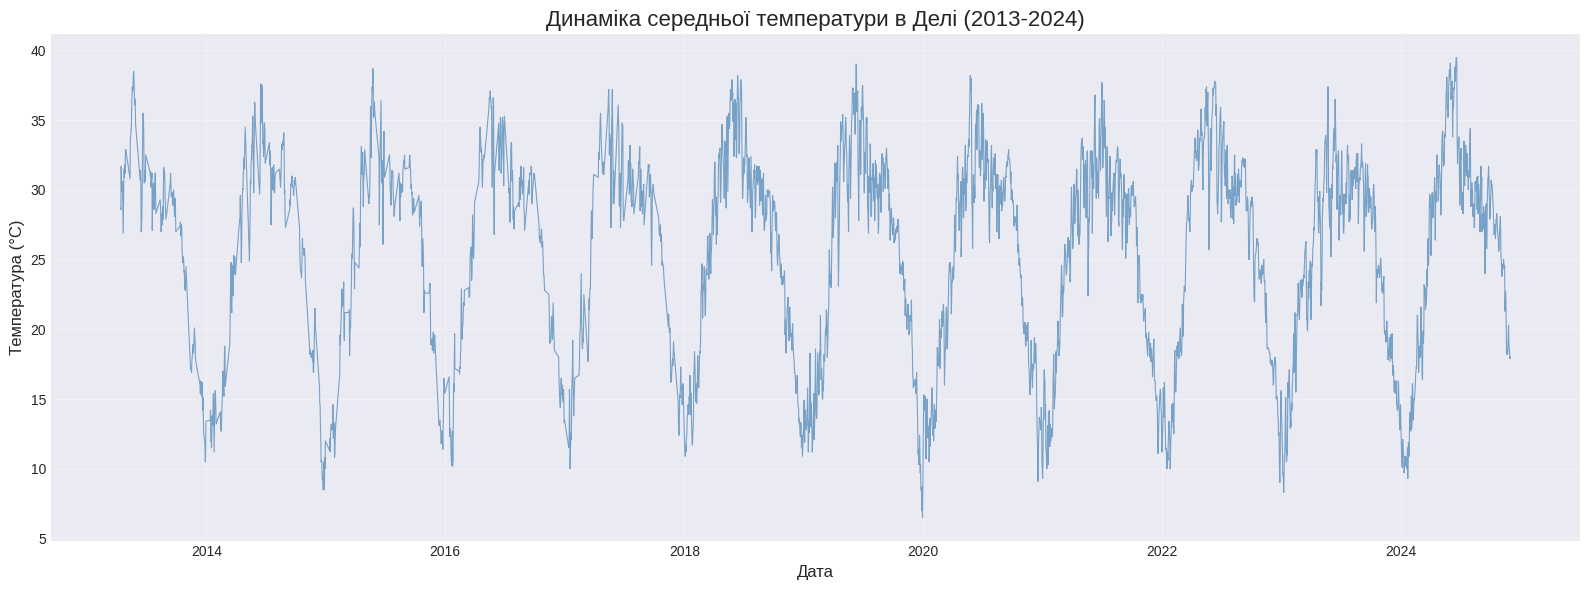

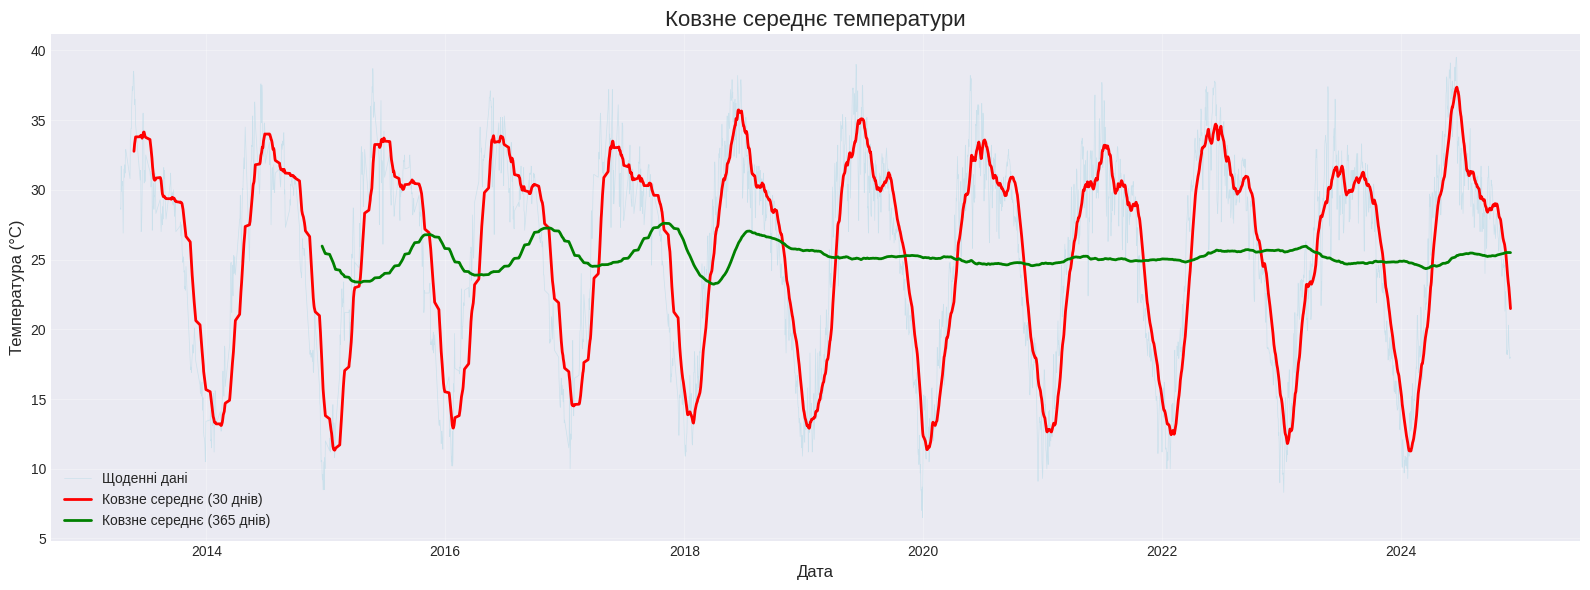

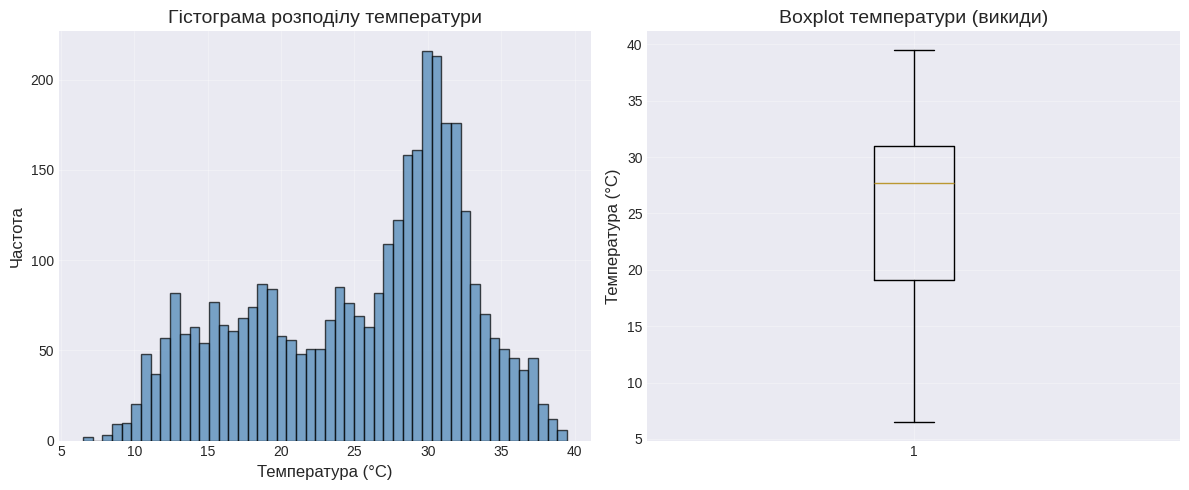

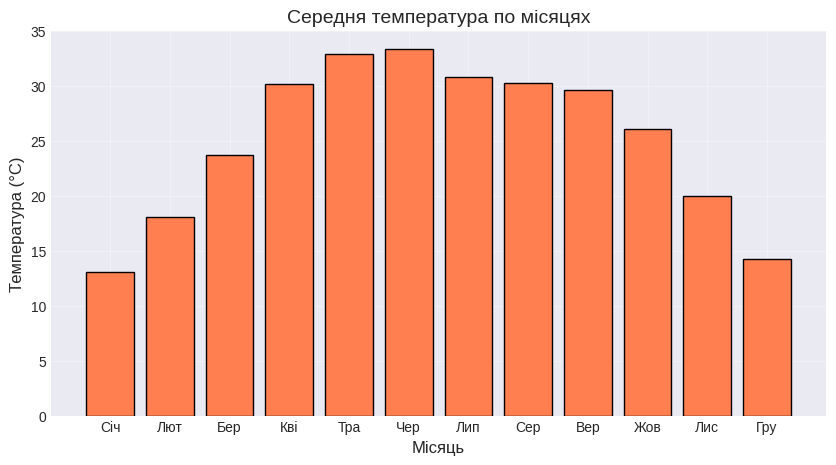

In [11]:
# Вибір цільової змінної для прогнозування
target_column = 'temp'  # середня температура

# 1. Графік зміни температури у часі
plt.figure(figsize=(16, 6))
plt.plot(df.index, df[target_column], color='steelblue', linewidth=0.8, alpha=0.7)
plt.title('Динаміка середньої температури в Делі (2013-2024)', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Ковзне середнє
plt.figure(figsize=(16, 6))
plt.plot(df.index, df[target_column], color='lightblue', linewidth=0.5, alpha=0.5, label='Щоденні дані')
plt.plot(df.index, df[target_column].rolling(window=30).mean(), color='red', linewidth=2, label='Ковзне середнє (30 днів)')
plt.plot(df.index, df[target_column].rolling(window=365).mean(), color='green', linewidth=2, label='Ковзне середнє (365 днів)')
plt.title('Ковзне середнє температури', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Гістограма розподілу температури
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df[target_column], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Гістограма розподілу температури', fontsize=14)
plt.xlabel('Температура (°C)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3)

# 4. Boxplot для виявлення викидів
plt.subplot(1, 2, 2)
plt.boxplot(df[target_column], vert=True)
plt.title('Boxplot температури (викиди)', fontsize=14)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Додатковий аналіз: сезонність
df['month'] = df.index.month
df['year'] = df.index.year

# Середня температура по місяцях
monthly_avg = df.groupby('month')[target_column].mean()
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='coral', edgecolor='black')
plt.title('Середня температура по місяцях', fontsize=14)
plt.xlabel('Місяць', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.xticks(range(1, 13), ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру'])
plt.grid(True, alpha=0.3)
plt.show()

Тест Дікі-Фуллера:
Статистика тесту: -5.8666
p-value: 0.0000
Критичні значення: {'1%': np.float64(-3.432205946405085), '5%': np.float64(-2.8623600521879315), '10%': np.float64(-2.5672065276952445)}
Ряд стаціонарний (відхиляємо H0)


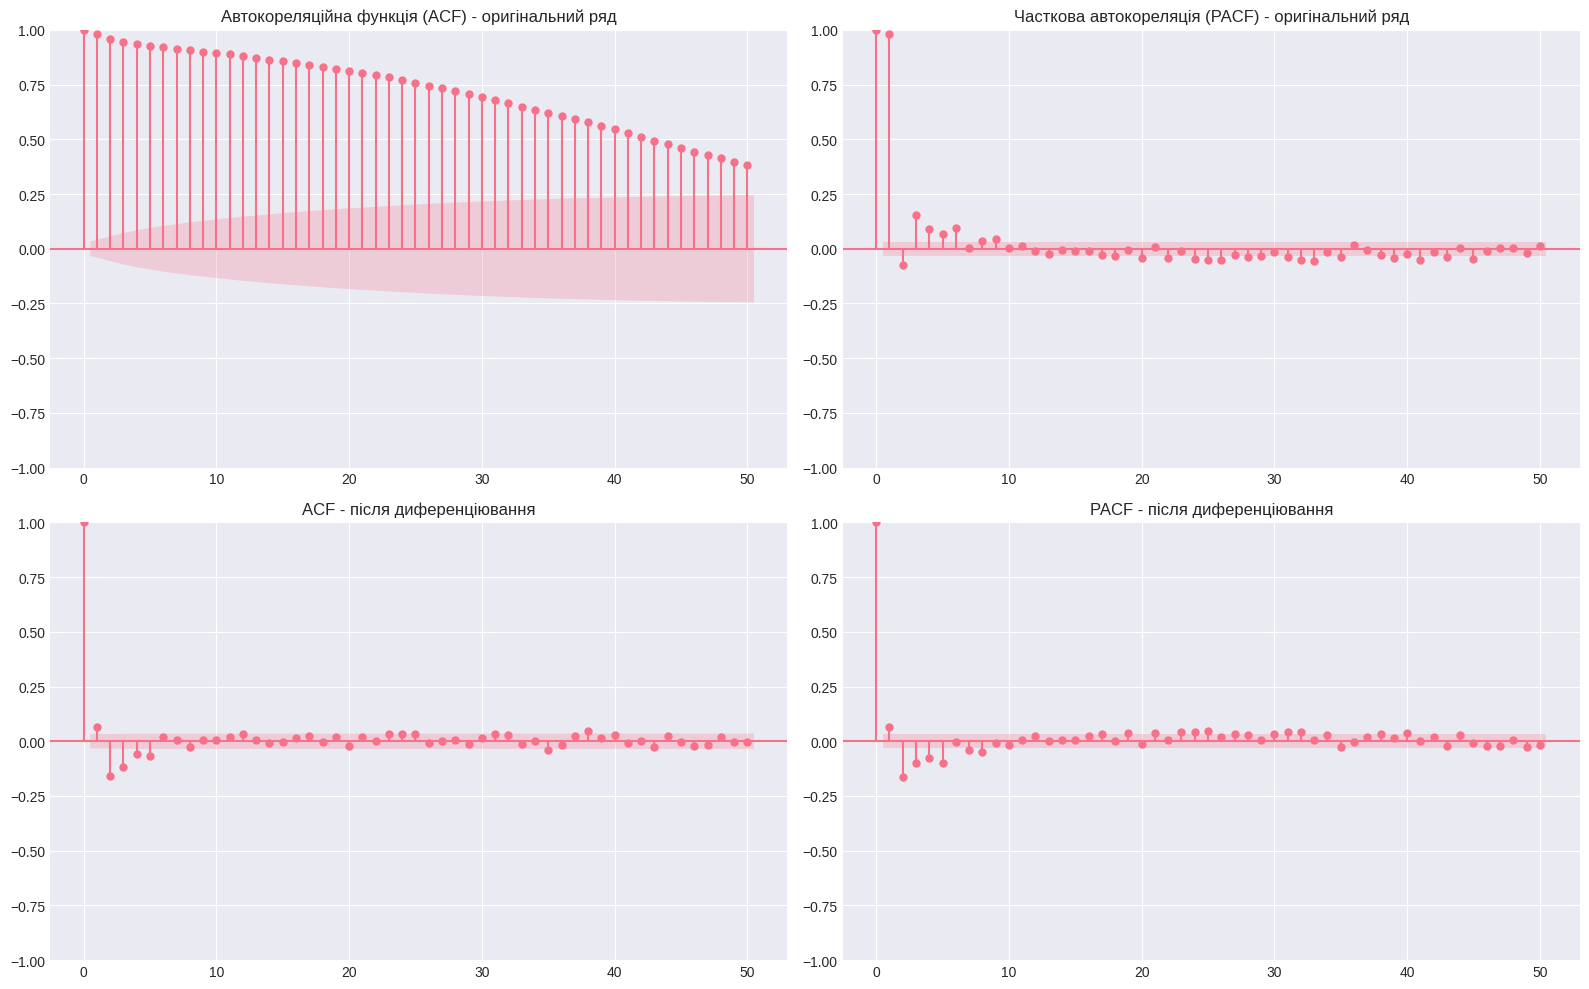


Аналіз автокореляції:
На графіках ACF видно сезонну компоненту з періодом ~365 днів
PACF показує значну кореляцію з лагами 1, 2 та сезонними лагами


In [12]:
# Перевірка стаціонарності (тест Дікі-Фуллера)
result = adfuller(df[target_column].dropna())
print('Тест Дікі-Фуллера:')
print(f'Статистика тесту: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Критичні значення: {result[4]}')

if result[1] <= 0.05:
    print("Ряд стаціонарний (відхиляємо H0)")
else:
    print("Ряд нестаціонарний (приймаємо H0)")

# Якщо ряд нестаціонарний, застосовуємо диференціювання
df_diff = df[target_column].diff().dropna()

# ACF та PACF
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF для оригінального ряду
plot_acf(df[target_column], lags=50, ax=axes[0, 0])
axes[0, 0].set_title('Автокореляційна функція (ACF) - оригінальний ряд')

# PACF для оригінального ряду
plot_pacf(df[target_column], lags=50, ax=axes[0, 1])
axes[0, 1].set_title('Часткова автокореляція (PACF) - оригінальний ряд')

# ACF для диференційованого ряду
plot_acf(df_diff, lags=50, ax=axes[1, 0])
axes[1, 0].set_title('ACF - після диференціювання')

# PACF для диференційованого ряду
plot_pacf(df_diff, lags=50, ax=axes[1, 1])
axes[1, 1].set_title('PACF - після диференціювання')

plt.tight_layout()
plt.show()

print("\nАналіз автокореляції:")
print("На графіках ACF видно сезонну компоненту з періодом ~365 днів")
print("PACF показує значну кореляцію з лагами 1, 2 та сезонними лагами")

In [13]:
# Розділення даних (80% тренування, 20% тест)
train_size = int(len(df) * 0.8)
train_data = df[target_column].iloc[:train_size]
test_data = df[target_column].iloc[train_size:]

print(f"Тренувальна вибірка: {len(train_data)} днів")
print(f"Тестова вибірка: {len(test_data)} днів")
print(f"Період тестування: з {test_data.index[0]} по {test_data.index[-1]}")

Тренувальна вибірка: 2845 днів
Тестова вибірка: 712 днів
Період тестування: з 2022-12-20 00:00:00 по 2024-11-30 00:00:00



МОДЕЛЬ 1: ARIMA
Підбір параметрів ARIMA...
Кращий порядок: (0, 0, 0), AIC: 19432.14
Кращий порядок: (0, 0, 1), AIC: 16154.34
Кращий порядок: (0, 0, 2), AIC: 13985.80
Кращий порядок: (0, 0, 3), AIC: 12961.31
Кращий порядок: (0, 0, 4), AIC: 12169.35
Кращий порядок: (0, 1, 0), AIC: 10110.90
Кращий порядок: (0, 1, 1), AIC: 10095.54
Кращий порядок: (0, 1, 2), AIC: 10026.95
Кращий порядок: (0, 1, 3), AIC: 9963.41
Кращий порядок: (0, 1, 4), AIC: 9961.78
Кращий порядок: (1, 0, 4), AIC: 9961.04
Кращий порядок: (1, 1, 2), AIC: 9960.40
Кращий порядок: (1, 1, 3), AIC: 9956.87
Кращий порядок: (2, 1, 1), AIC: 9955.14
Кращий порядок: (2, 1, 3), AIC: 9955.12
Кращий порядок: (3, 1, 4), AIC: 9951.30
Кращий порядок: (4, 1, 3), AIC: 9947.99

Оптимальні параметри ARIMA: order=(4, 1, 3)

Звіт моделі ARIMA:
                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2845
Model:                 ARIMA(4, 1, 3)   Log L

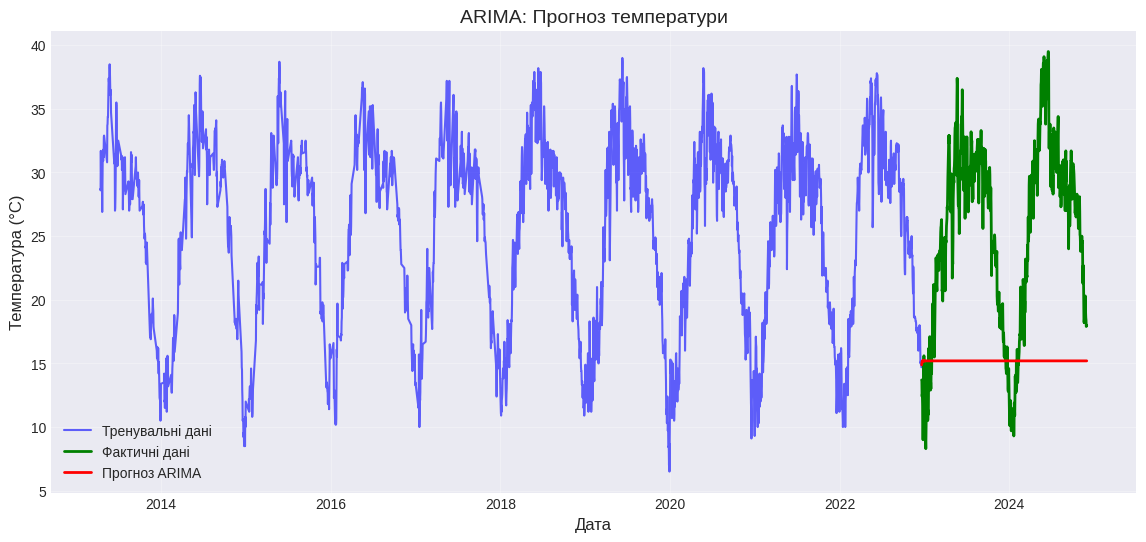

In [7]:
# ARIMA модель
print("\n" + "="*50)
print("МОДЕЛЬ 1: ARIMA")
print("="*50)


# Підбір оптимальних параметрів
best_aic = float('inf')
best_order = None

print("Підбір параметрів ARIMA...")
for p in range(0, 5):
    for d in range(0, 2):
        for q in range(0, 5):
            try:
                model = ARIMA(train_data, order=(p, d, q))
                model_fit = model.fit()
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)
                    print(f"Кращий порядок: {best_order}, AIC: {best_aic:.2f}")
            except:
                continue

print(f"\nОптимальні параметри ARIMA: order={best_order}")

# Побудова моделі з оптимальними параметрами
arima_model = ARIMA(train_data, order=best_order)
arima_fit = arima_model.fit()

print("\nЗвіт моделі ARIMA:")
print(arima_fit.summary())

# Прогнозування
arima_forecast = arima_fit.forecast(steps=len(test_data))

# Візуалізація ARIMA
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data, label='Тренувальні дані', color='blue', alpha=0.6)
plt.plot(test_data.index, test_data, label='Фактичні дані', color='green', linewidth=2)
plt.plot(test_data.index, arima_forecast, label='Прогноз ARIMA', color='red', linewidth=2)
plt.title('ARIMA: Прогноз температури', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


МОДЕЛЬ 2: Prophet


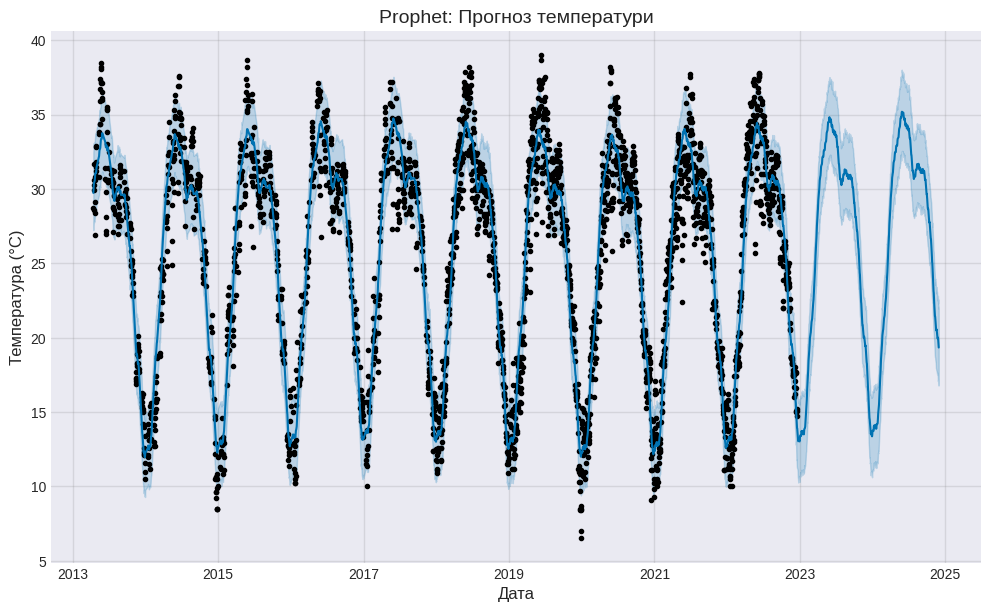

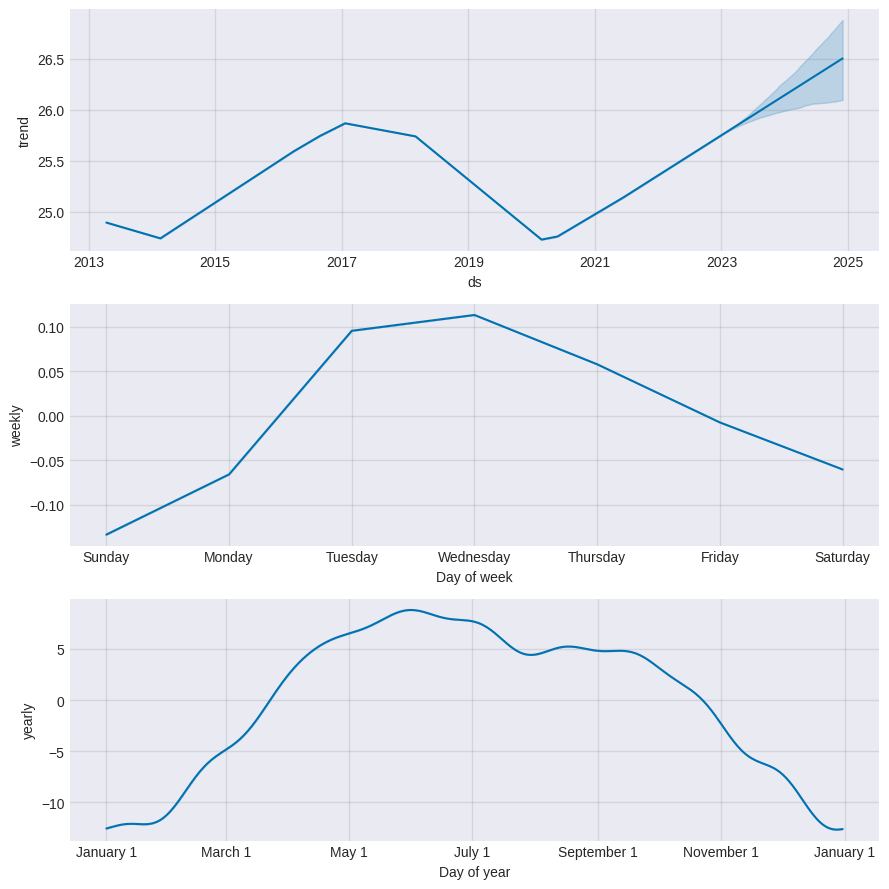

In [14]:
print("\n" + "="*50)
print("МОДЕЛЬ 2: Prophet")
print("="*50)

# Підготовка даних для Prophet
prophet_df = pd.DataFrame({
    'ds': train_data.index,
    'y': train_data.values
})

# Створення та навчання моделі Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(prophet_df)

# Створення датафрейму для прогнозування
future = prophet_model.make_future_dataframe(periods=len(test_data))
forecast = prophet_model.predict(future)

# Отримання прогнозу на тестовий період
prophet_forecast = forecast.set_index('ds')['yhat'].loc[test_data.index]

# Візуалізація Prophet
fig = prophet_model.plot(forecast)
plt.title('Prophet: Прогноз температури', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.show()

fig2 = prophet_model.plot_components(forecast)
plt.show()


МОДЕЛЬ 3: LSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.0348 - val_loss: 0.0057
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0092 - val_loss: 0.0047
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0082 - val_loss: 0.0047
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0077 - val_loss: 0.0044
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0073 - val_loss: 0.0042
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0071 - val_loss: 0.0049
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0064 - val_loss: 0.0041
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0061 - val_loss: 0.0043
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0061 - val_loss: 0.0041
Epoch 10/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0055 - val_loss: 0.0039
Epoch 11/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0052 - val_loss: 0.0035
Epoch 12/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/ste

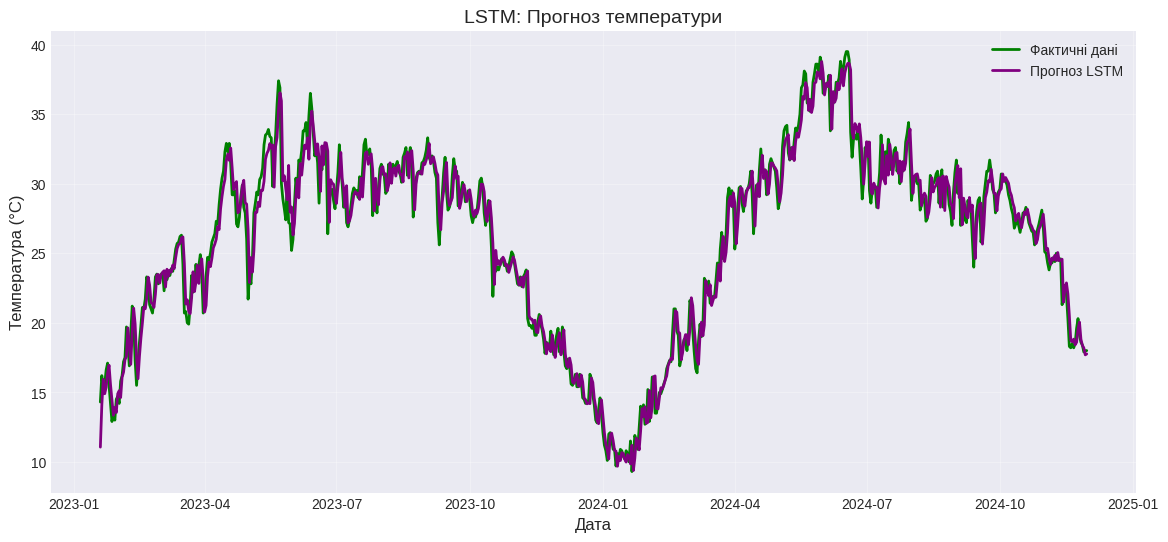

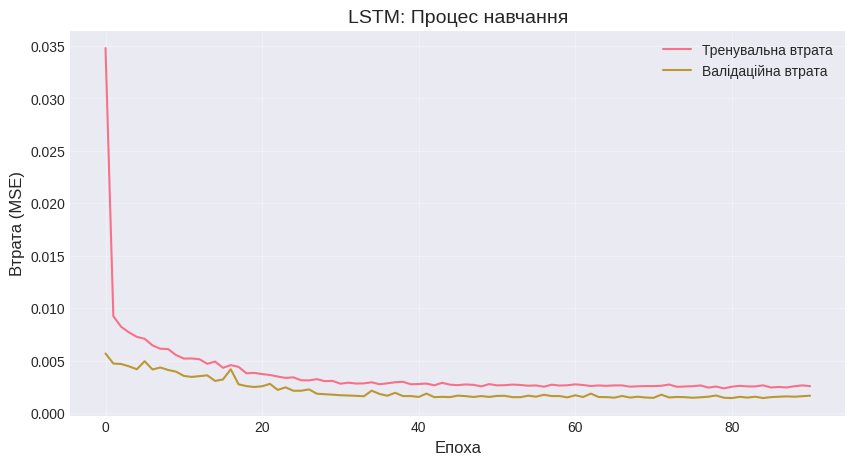

In [15]:
print("\n" + "="*50)
print("МОДЕЛЬ 3: LSTM")
print("="*50)

# Підготовка даних для LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))
test_scaled = scaler.transform(test_data.values.reshape(-1, 1))

# Функція для створення послідовностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Параметри LSTM
seq_length = 30  # використовуємо останні 30 днів для прогнозу
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# Побудова LSTM моделі
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# Навчання моделі
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Прогнозування
lstm_predictions_scaled = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

# Підготовка фактичних значень для порівняння
y_test_actual = scaler.inverse_transform(y_test)

# Візуалізація LSTM
plt.figure(figsize=(14, 6))
plt.plot(test_data.index[seq_length:], y_test_actual, label='Фактичні дані', color='green', linewidth=2)
plt.plot(test_data.index[seq_length:], lstm_predictions, label='Прогноз LSTM', color='purple', linewidth=2)
plt.title('LSTM: Прогноз температури', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Графік навчання LSTM
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Тренувальна втрата')
plt.plot(history.history['val_loss'], label='Валідаційна втрата')
plt.title('LSTM: Процес навчання', fontsize=14)
plt.xlabel('Епоха', fontsize=12)
plt.ylabel('Втрата (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


ОЦІНКА МОДЕЛЕЙ

Таблиця порівняння моделей:
 Модель   MAE  RMSE MAPE (%)
  ARIMA 10.90 12.47    39.49
Prophet  2.00  2.59     9.01
   LSTM  0.99  1.30     4.05


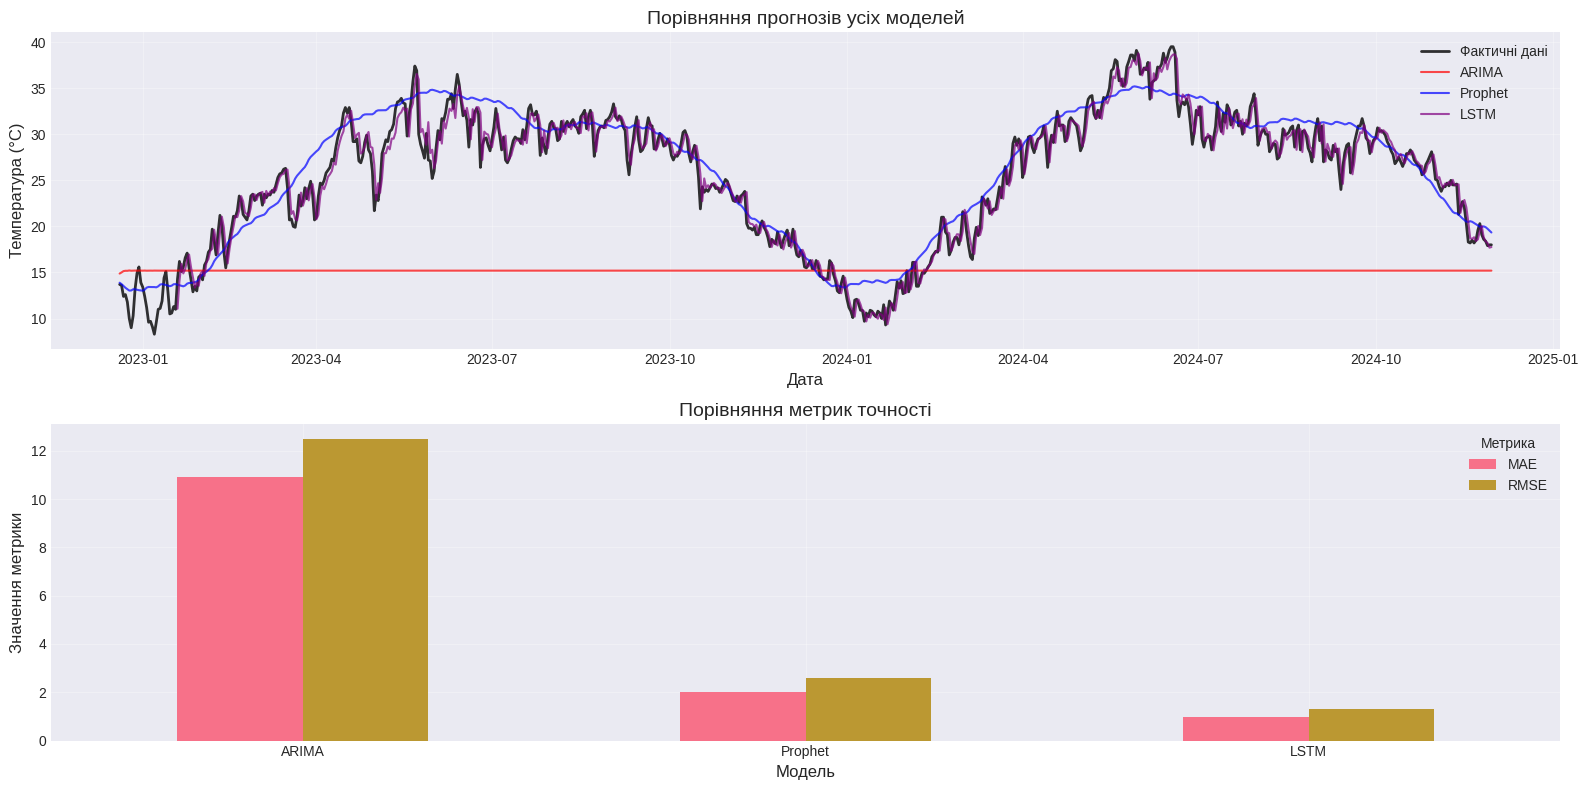


ВИСНОВКИ
Найкраща модель за MAE: LSTM
Найкраща модель за RMSE: LSTM
Найкраща модель за MAPE: LSTM


In [16]:
print("\n" + "="*50)
print("ОЦІНКА МОДЕЛЕЙ")
print("="*50)

# Функція для обчислення метрик
def calculate_metrics(actual, predicted, model_name):
    # Вирівнювання довжин даних
    min_len = min(len(actual), len(predicted))
    actual = actual[:min_len]
    predicted = predicted[:min_len]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        'Модель': model_name,
        'MAE': f'{mae:.2f}',
        'RMSE': f'{rmse:.2f}',
        'MAPE (%)': f'{mape:.2f}'
    }

# Збір метрик для кожної моделі
results = []

# ARIMA
arima_actual = test_data.values
arima_pred = arima_forecast.values
results.append(calculate_metrics(arima_actual, arima_pred, 'ARIMA'))

# Prophet
prophet_actual = test_data.values
prophet_pred = prophet_forecast.values
results.append(calculate_metrics(prophet_actual, prophet_pred, 'Prophet'))

# LSTM
lstm_actual = y_test_actual.flatten()
lstm_pred = lstm_predictions.flatten()
results.append(calculate_metrics(lstm_actual, lstm_pred, 'LSTM'))

# Створення таблиці результатів
results_df = pd.DataFrame(results)
print("\nТаблиця порівняння моделей:")
print(results_df.to_string(index=False))

# Порівняльна візуалізація
plt.figure(figsize=(16, 8))

# Графік прогнозів
plt.subplot(2, 1, 1)
plt.plot(test_data.index, test_data, label='Фактичні дані', color='black', linewidth=2, alpha=0.8)
plt.plot(test_data.index, arima_forecast, label='ARIMA', color='red', linewidth=1.5, alpha=0.7)
plt.plot(test_data.index, prophet_forecast, label='Prophet', color='blue', linewidth=1.5, alpha=0.7)

# Для LSTM (з урахуванням зсуву)
lstm_index = test_data.index[seq_length:]
plt.plot(lstm_index, lstm_predictions, label='LSTM', color='purple', linewidth=1.5, alpha=0.7)

plt.title('Порівняння прогнозів усіх моделей', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Графік метрик
plt.subplot(2, 1, 2)
metrics_plot = results_df.set_index('Модель')[['MAE', 'RMSE']].astype(float)
metrics_plot.plot(kind='bar', rot=0, ax=plt.gca())
plt.title('Порівняння метрик точності', fontsize=14)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('Значення метрики', fontsize=12)
plt.legend(title='Метрика')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Визначення найкращої моделі
metrics_numeric = results_df.copy()
metrics_numeric['MAE'] = metrics_numeric['MAE'].astype(float)
metrics_numeric['RMSE'] = metrics_numeric['RMSE'].astype(float)
metrics_numeric['MAPE (%)'] = metrics_numeric['MAPE (%)'].astype(float)

best_mae = metrics_numeric.loc[metrics_numeric['MAE'].idxmin(), 'Модель']
best_rmse = metrics_numeric.loc[metrics_numeric['RMSE'].idxmin(), 'Модель']
best_mape = metrics_numeric.loc[metrics_numeric['MAPE (%)'].idxmin(), 'Модель']

print("\n" + "="*50)
print("ВИСНОВКИ")
print("="*50)
print(f"Найкраща модель за MAE: {best_mae}")
print(f"Найкраща модель за RMSE: {best_rmse}")
print(f"Найкраща модель за MAPE: {best_mape}")